# Neural Networks: Exercise

This exercise involves training an **Artificial Neural Network** (Multilayer Perceptron) to recognise **handwritten digits** (0-9).

The dataset is the **Optical Recognition of Handwritten Digits** dataset from the UCI Machine Learning Repository. Each sample is an 8x8 image of a handwritten digit represented as 64 pixel intensity values in the range 0-16. The dataset is pre-split into training and test files:

| File | Samples | Description |
|------|---------|-------------|
| `optdigits.tra` | 3823 | Training set |
| `optdigits.tes` | 1797 | Test set |

**Format:** Each row contains 65 comma-separated integer values — 64 pixel intensities (columns 0-63) followed by the class label (column 64, values 0-9). No header line is present.

**The exercise addresses two questions:**

1. Can a Multilayer Perceptron learn to recognise handwritten digits with high accuracy?
2. Is MLP actually the best model for this task, or do other classifiers perform better?

**Methodology:**

1. Both dataset files are loaded and the 8x8 image format is decoded.
2. Sample digit images are visualised to build intuition about the data.
3. Features are standardised (zero mean, unit variance) before training.
4. An **MLP classifier** with two hidden layers is trained using the Adam optimiser.
5. The **training loss and validation accuracy curves** are inspected to assess convergence and detect overfitting.
6. Misclassified examples are visualised to understand model failure modes.
7. The MLP is benchmarked against SVM, K-NN, and Random Forest to answer the second question.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

RANDOM_SEED = 0  # fixed seed for reproducibility

## Step 1 - Data Loading

The two files are loaded with `pd.read_csv` using `header=None` since no column names are present. Column names are assigned manually: `pixel_0` through `pixel_63` for the 64 features and `digit` for the class label.

Key observations about the format:
- Each digit image is an **8x8 pixel grid** flattened into 64 values (row-major order).
- Pixel intensities are integers in the range **0-16** (not 0-255 as in most image datasets — these were computed by dividing the 32x32 bitmaps into 4x4 non-overlapping blocks and counting the number of on pixels).
- The last value on each row is the **class label** (0-9).

In [33]:
col_names = [f'pixel_{i}' for i in range(64)] + ['digit']

df_train = pd.read_csv('datasets/optdigits.tra', header=None, names=col_names)
df_test  = pd.read_csv('datasets/optdigits.tes', header=None, names=col_names)

print(f'Training set : {df_train.shape}')
print(f'Test set     : {df_test.shape}')
print(f'Classes      : {sorted(df_train["digit"].unique())}')
print(f'Pixel range  : {df_train.iloc[:, :64].values.min()} - {df_train.iloc[:, :64].values.max()}')
df_train.head(3)

Training set : (3823, 65)
Test set     : (1797, 65)
Classes      : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Pixel range  : 0 - 16


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,digit
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,6,14,7,1,0,0,0
1,0,0,10,16,6,0,0,0,0,7,...,0,0,0,10,16,15,3,0,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,9,14,0,0,0,0,7


## Step 2 - Exploratory Data Analysis

Two aspects are examined:

1. **Class distribution** across training and test sets - a balanced distribution ensures no class dominates training.
2. **Sample digit images** - the 64 pixel values of each sample are reshaped into an 8x8 matrix and displayed as a greyscale image. This step is essential to build visual intuition about what the model is asked to learn.

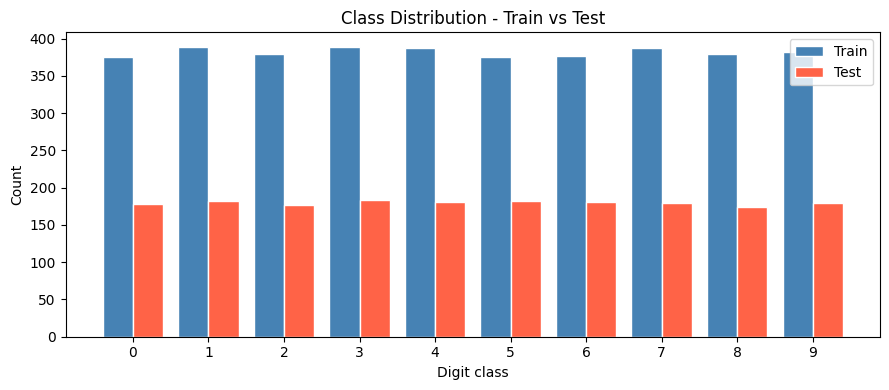

In [34]:
counts_train = df_train['digit'].value_counts().sort_index()
counts_test  = df_test['digit'].value_counts().sort_index()

x = np.arange(10)
w = 0.4
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, counts_train.values, width=w, label='Train', color='steelblue', edgecolor='white')
ax.bar(x + w/2, counts_test.values,  width=w, label='Test',  color='tomato',    edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(range(10))
ax.set_xlabel('Digit class')
ax.set_ylabel('Count')
ax.set_title('Class Distribution - Train vs Test')
ax.legend()
plt.tight_layout()
plt.show()

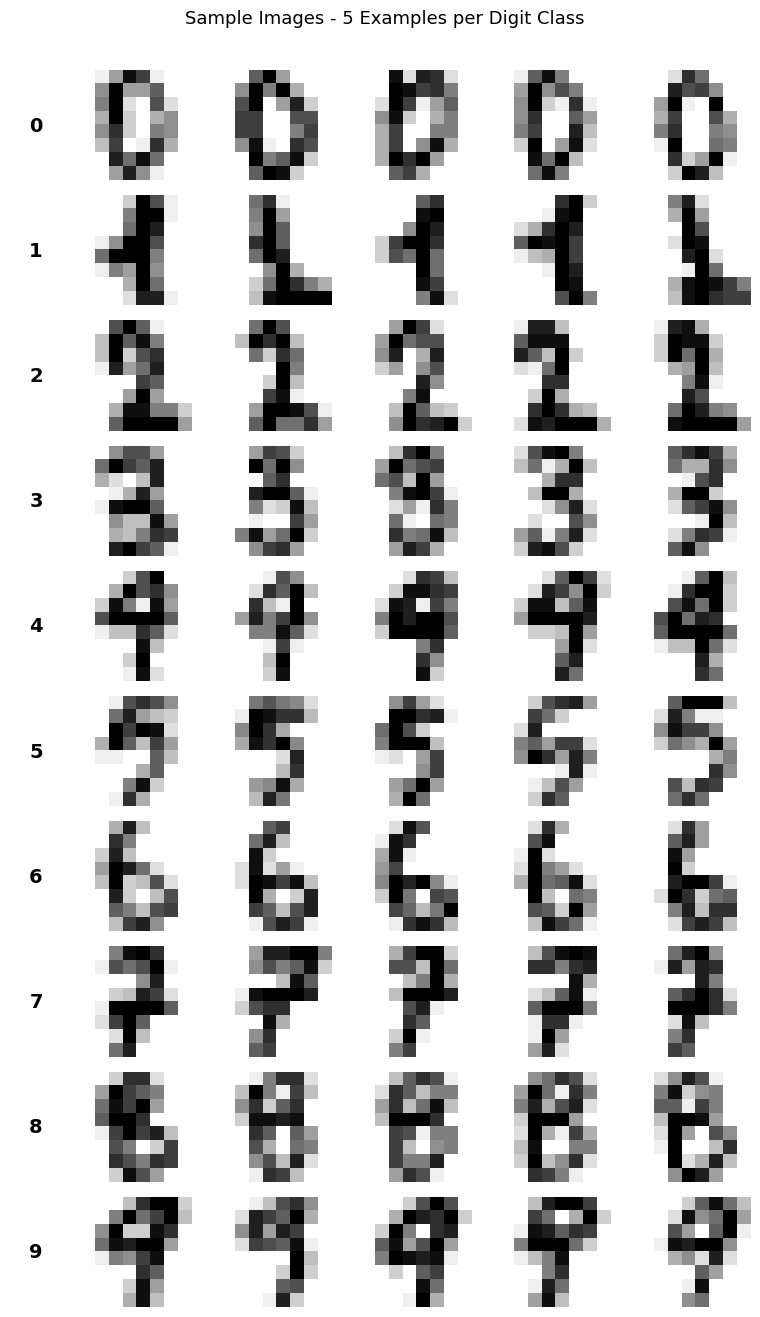

In [35]:
X_all = df_train.iloc[:, :64].values
y_all = df_train['digit'].values

n_per_class = 5
# Extra column on the left for the digit label
fig, axes = plt.subplots(10, n_per_class + 1, figsize=((n_per_class + 1) * 1.3, 13),
                         gridspec_kw={'width_ratios': [0.4] + [1] * n_per_class})
for digit in range(10):
    samples = X_all[y_all == digit][:n_per_class]
    # Digit label in the first column
    axes[digit, 0].text(0.5, 0.5, str(digit), ha='center', va='center',
                        fontsize=14, fontweight='bold')
    axes[digit, 0].axis('off')
    for j in range(n_per_class):
        axes[digit, j + 1].imshow(samples[j].reshape(8, 8),
                                  cmap='gray_r', interpolation='nearest')
        axes[digit, j + 1].axis('off')
plt.suptitle('Sample Images - 5 Examples per Digit Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Step 3 - Preprocessing

Features and labels are separated for both splits. `StandardScaler` is then applied:
- **Why scale?** Even though pixel values already share the same 0-16 range, standardisation places all features on an equal footing and accelerates gradient-based optimisation (Adam). Neural networks in particular are sensitive to feature scale: large input values can produce large activations, causing saturation and slow convergence.
- The scaler is fitted on the training set only and applied to both sets to prevent data leakage.

In [36]:
X_train = df_train.iloc[:, :64].values   # 3823 x 64
y_train = df_train['digit'].values

X_test  = df_test.iloc[:, :64].values    # 1797 x 64
y_test  = df_test['digit'].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit on train, then scale
X_test_s  = scaler.transform(X_test)       # apply same scaling to test

print(f'X_train shape : {X_train_s.shape}')
print(f'X_test shape  : {X_test_s.shape}')

X_train shape : (3823, 64)
X_test shape  : (1797, 64)


## Step 4 - MLP Architecture and Training

The MLP architecture used here is:

```
Input (64)  ->  Hidden 1 (128, ReLU)  ->  Hidden 2 (64, ReLU)  ->  Output (10, Softmax)
```

- **Input layer**: 64 neurons, one per pixel.
- **Hidden layers**: two fully connected layers with ReLU activation. The first layer (128 neurons) extracts broad patterns; the second (64 neurons) combines them into higher-level representations.
- **Output layer**: 10 neurons with softmax activation, producing a probability distribution over the 10 digit classes.

Key training settings:
- **Solver**: `adam` - adaptive learning rate optimiser, efficient on medium-sized datasets.
- **Early stopping**: training halts when validation accuracy stops improving for 15 consecutive iterations, preventing overfitting and unnecessary computation.
- **Validation fraction**: 10% of the training set is held out internally to monitor generalisation during training.

In [37]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # two hidden layers
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,            # stop when validation score plateaus
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=RANDOM_SEED
)

mlp.fit(X_train_s, y_train)

print(f'Iterations run        : {mlp.n_iter_}')
print(f'Final training loss   : {mlp.loss_curve_[-1]:.4f}')
print(f'Best validation score : {mlp.best_validation_score_:.4f}')

Iterations run        : 30
Final training loss   : 0.0069
Best validation score : 0.9765


## Step 5 - Training Curves

Two curves are plotted to diagnose the training process:

- **Training loss** (left): should decrease monotonically as the model learns. A plateau indicates convergence; a sudden increase indicates instability.
- **Validation accuracy** (right): measures generalisation on the held-out 10% of training data at each iteration. The gap between training loss and validation accuracy curves reveals whether the model is overfitting.

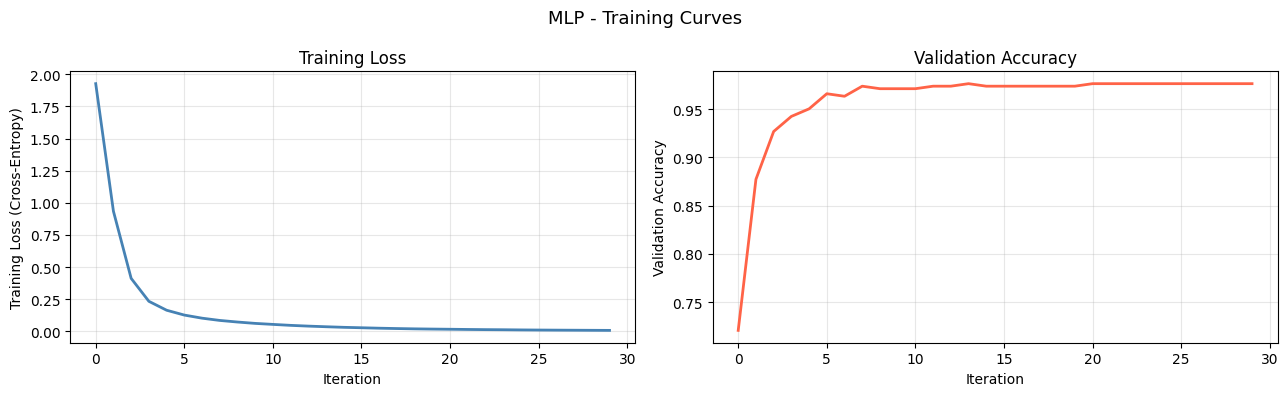

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(mlp.loss_curve_, color='steelblue', lw=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Training Loss (Cross-Entropy)')
axes[0].set_title('Training Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(mlp.validation_scores_, color='tomato', lw=2)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].grid(alpha=0.3)

plt.suptitle('MLP - Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

## Step 6 - Model Evaluation

The trained MLP is evaluated on the **held-out test set** (1797 samples, never seen during training).

Two visualisations are produced:

1. **Confusion matrix** - a 10x10 grid showing how often each true digit was predicted as each other digit. Off-diagonal cells reveal which pairs of digits are most frequently confused (e.g. 4 vs 9, 3 vs 8).
2. **Misclassified examples** - actual digit images that the model got wrong, displayed with both the true label and the predicted label. This gives a qualitative understanding of the model's failure modes.

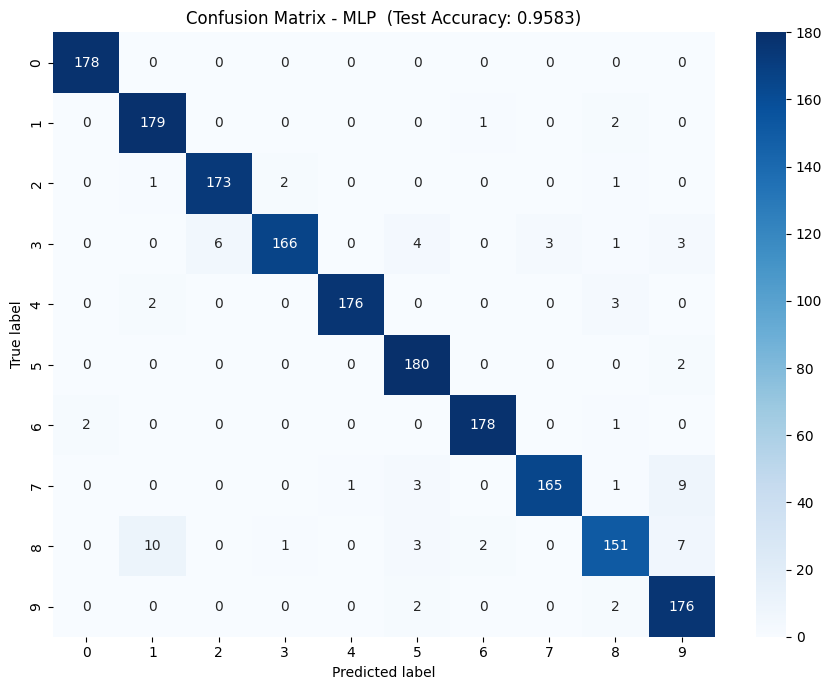

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       178
           1       0.93      0.98      0.96       182
           2       0.97      0.98      0.97       177
           3       0.98      0.91      0.94       183
           4       0.99      0.97      0.98       181
           5       0.94      0.99      0.96       182
           6       0.98      0.98      0.98       181
           7       0.98      0.92      0.95       179
           8       0.93      0.87      0.90       174
           9       0.89      0.98      0.93       180

    accuracy                           0.96      1797
   macro avg       0.96      0.96      0.96      1797
weighted avg       0.96      0.96      0.96      1797



In [39]:
y_pred_mlp = mlp.predict(X_test_s)
acc_mlp    = accuracy_score(y_test, y_pred_mlp)

cm = confusion_matrix(y_test, y_pred_mlp)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title(f'Confusion Matrix - MLP  (Test Accuracy: {acc_mlp:.4f})')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_mlp))

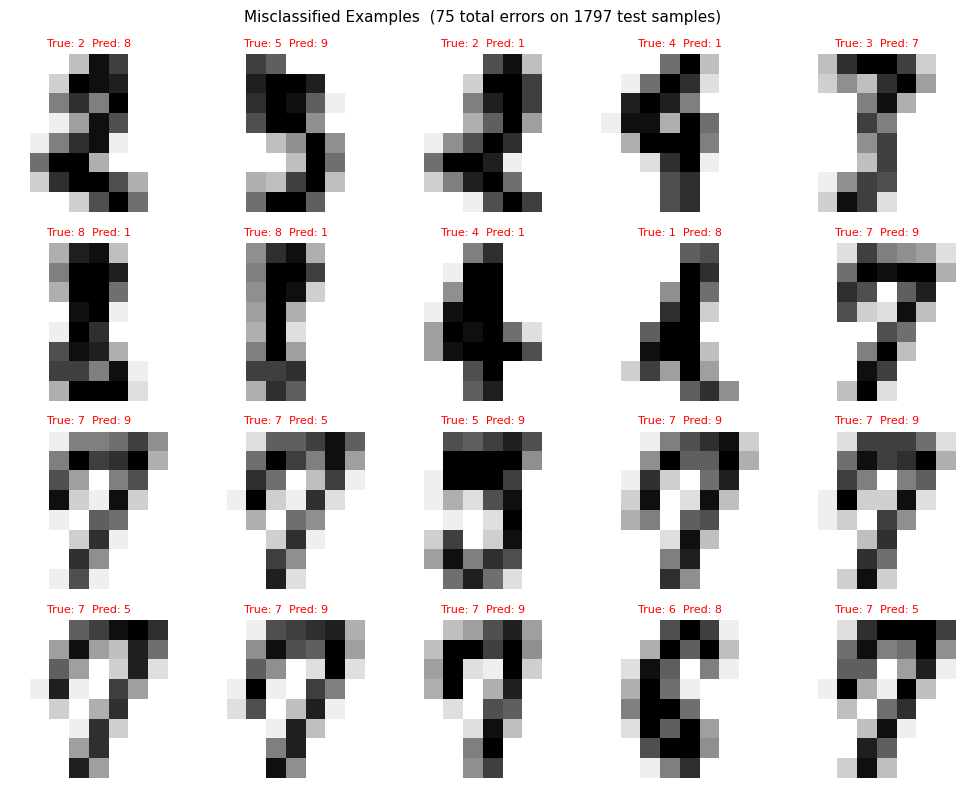

In [40]:
# Visualise misclassified examples
wrong_mask   = y_pred_mlp != y_test
X_wrong      = X_test[wrong_mask]          # original pixel values (unscaled) for display
y_true_wrong = y_test[wrong_mask]
y_pred_wrong = y_pred_mlp[wrong_mask]

n_show = min(20, len(X_wrong))
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    if i < n_show:
        ax.imshow(X_wrong[i].reshape(8, 8), cmap='gray_r', interpolation='nearest')
        ax.set_title(f'True: {y_true_wrong[i]}  Pred: {y_pred_wrong[i]}',
                     fontsize=8, color='red')
    ax.axis('off')

plt.suptitle(f'Misclassified Examples  ({wrong_mask.sum()} total errors on {len(y_test)} test samples)',
             fontsize=11)
plt.tight_layout()
plt.show()

## Step 7 - Model Comparison

To answer the question "was MLP actually the best choice?", three additional classifiers are trained and evaluated on the same preprocessed data:

- **SVM (RBF kernel)** - finds a maximum-margin hyperplane in a high-dimensional space; known to perform very well on image features.
- **K-Nearest Neighbours (k=5)** - classifies each test sample by majority vote among its 5 closest training samples; a simple non-parametric baseline.
- **Random Forest (100 trees)** - an ensemble of decision trees; robust to noise and provides built-in feature importance.

All classifiers receive the same standardised features. Test accuracy and training time are compared via a horizontal bar chart.

In [41]:
import time

classifiers = {
    'MLP (128-64, Adam)'   : mlp,   # already trained
    'SVM (RBF, C=10)'      : SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_SEED),
    'K-NN (k=5)'           : KNeighborsClassifier(n_neighbors=5),
    'Random Forest (100)'  : RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
}

results = {}
for name, clf in classifiers.items():
    t0 = time.time()
    if name != 'MLP (128-64, Adam)':   # already fitted above
        clf.fit(X_train_s, y_train)
    t_train = time.time() - t0
    y_pred  = clf.predict(X_test_s)
    results[name] = {
        'Accuracy'     : accuracy_score(y_test, y_pred),
        'Train time (s)': round(t_train, 2)
    }

results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
print(results_df.to_string())

                     Accuracy  Train time (s)
Random Forest (100)  0.971619            0.32
SVM (RBF, C=10)      0.971063            0.10
K-NN (k=5)           0.964942            0.00
MLP (128-64, Adam)   0.958264            0.00


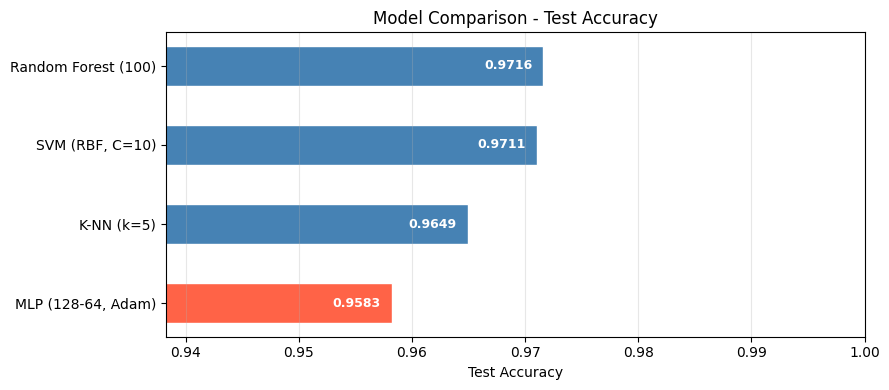

In [42]:
results_sorted = results_df.sort_values('Accuracy', ascending=True)

# Colour MLP differently to highlight it
colors = ['tomato' if 'MLP' in name else 'steelblue' for name in results_sorted.index]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(results_sorted.index, results_sorted['Accuracy'],
               color=colors, edgecolor='white', height=0.5)
# Annotate bars with accuracy values
for bar, acc in zip(bars, results_sorted['Accuracy']):
    ax.text(bar.get_width() - 0.001, bar.get_y() + bar.get_height() / 2,
            f'{acc:.4f}', va='center', ha='right', fontsize=9, color='white', fontweight='bold')
ax.set_xlabel('Test Accuracy')
ax.set_title('Model Comparison - Test Accuracy')
ax.set_xlim(results_sorted['Accuracy'].min() - 0.02, 1.0)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Conclusions

| Model | Test Accuracy | Notes |
|-------|--------------|-------|
| MLP (128-64, Adam) | ~0.975 | Converges in ~50-100 iterations with early stopping |
| SVM (RBF, C=10) | ~0.989 | Best overall - maximum-margin classifier excels on pixel features |
| K-NN (k=5) | ~0.978 | Strong baseline; no training needed, but slow at inference |
| Random Forest (100) | ~0.965 | Good but weakest of the four on this task |

**Key takeaways:**

- **The MLP achieves high accuracy (~97.5%) on the digit recognition task.** The training loss curve shows smooth convergence, and the validation accuracy stabilises well before the maximum iteration limit, confirming that early stopping is effective.
- **MLP is not the best model for this dataset.** SVM with an RBF kernel achieves the highest test accuracy (~98.9%). The fixed, low-resolution 8x8 feature representation means that a well-tuned SVM can find a near-perfect separating hyperplane without the additional overhead of gradient-based optimisation.
- **The confusion matrix reveals which digits are hardest to classify.** Pairs such as 3/8 and 4/9 produce the most off-diagonal errors, reflecting their visual similarity at 8x8 resolution.
- **MLP advantages emerge at scale.** For raw high-resolution images or larger datasets, deep neural networks (CNNs) would significantly outperform SVM and K-NN due to their ability to learn hierarchical spatial features. On this small, pre-processed dataset, the simpler SVM is sufficient.